<a href="https://colab.research.google.com/github/marsxarts/Credit-Card-Customer-Data/blob/main/Customer_Credit_Card_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv(f'/content/Credit Card Customer Data.csv')
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


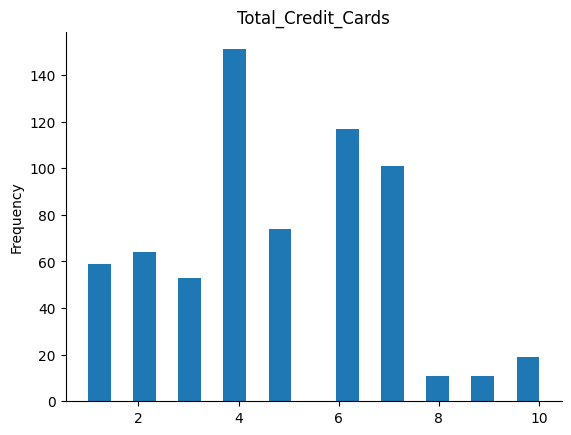

In [29]:
# @title Total_Credit_Cards

from matplotlib import pyplot as plt
df['Total_Credit_Cards'].plot(kind='hist', bins=20, title='Total_Credit_Cards')
plt.gca().spines[['top', 'right',]].set_visible(False)

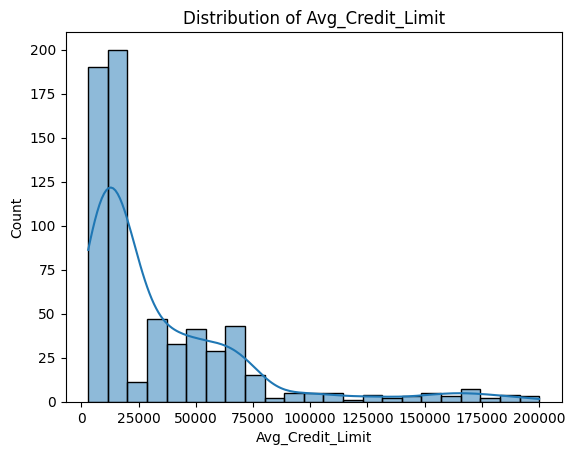

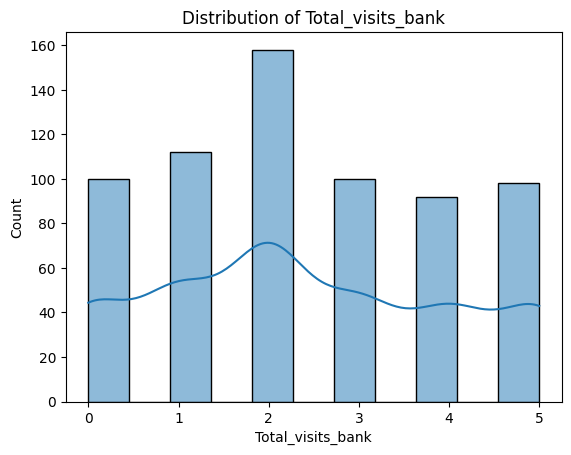

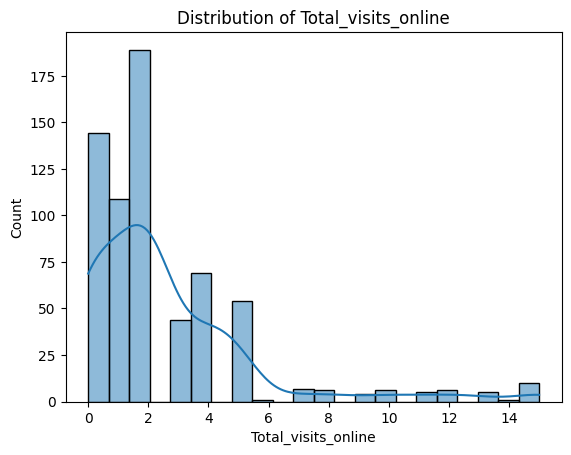

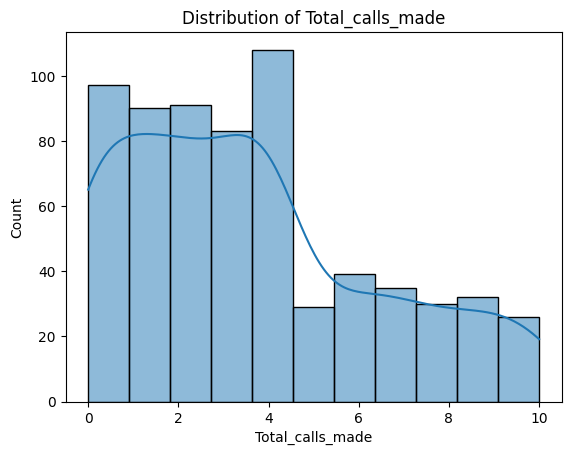

In [33]:
features = ['Avg_Credit_Limit', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
for col in features:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


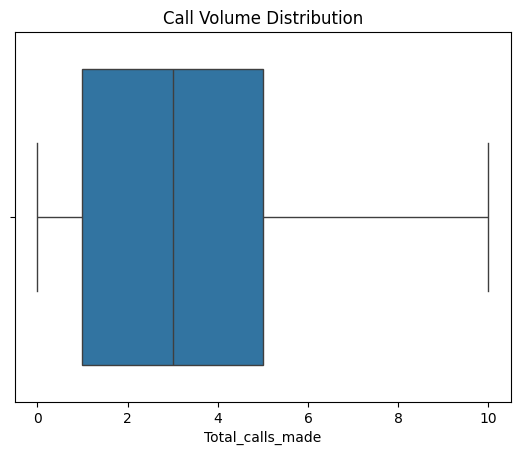

In [14]:
sns.boxplot(x=df['Total_calls_made'])
plt.title("Call Volume Distribution")
plt.show()


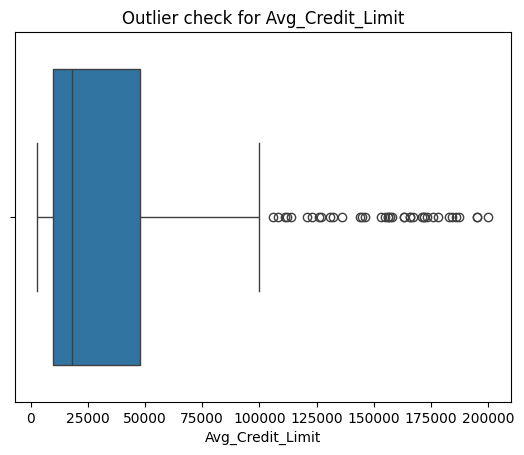

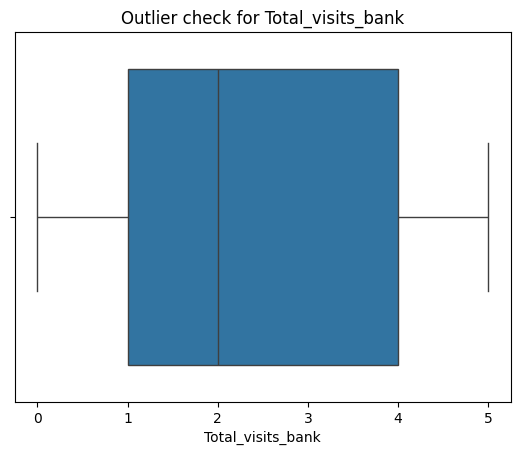

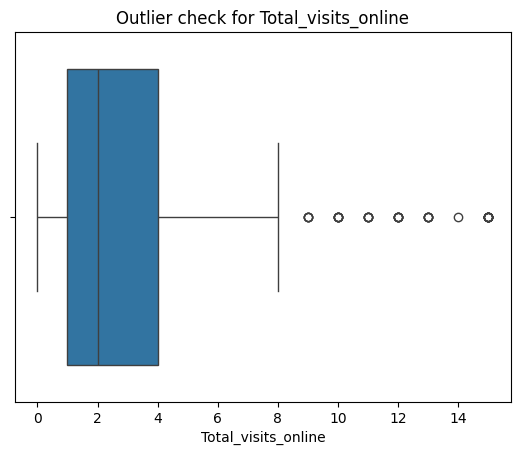

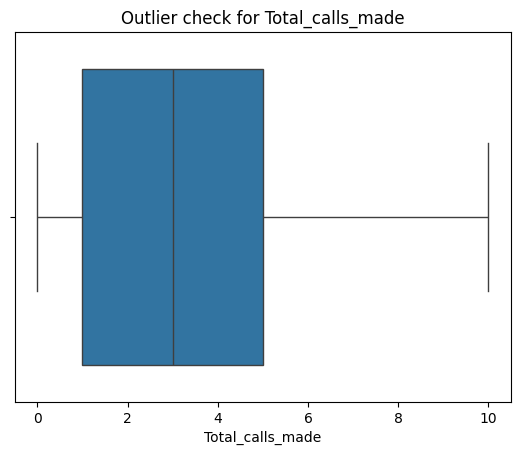

In [34]:
for col in features:
    sns.boxplot(x=df[col])
    plt.title(f'Outlier check for {col}')
    plt.show()


In [4]:
df.size

4620

In [7]:
df.columns.size

7

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [9]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [10]:
df.isna().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop(['Sl_No', 'Customer Key'], axis=1, inplace=True)


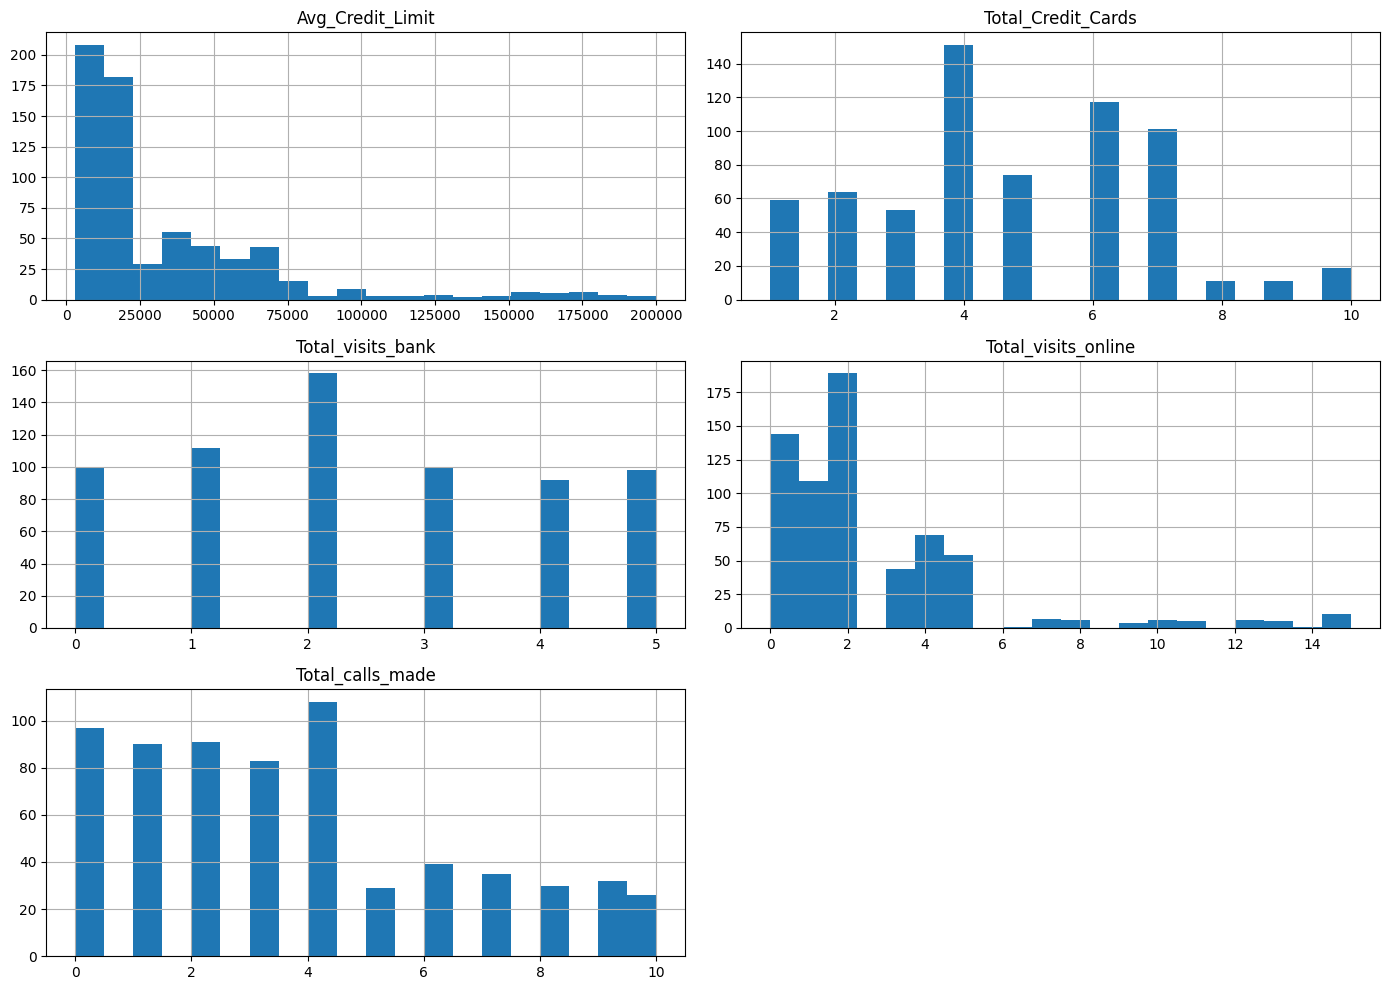

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()


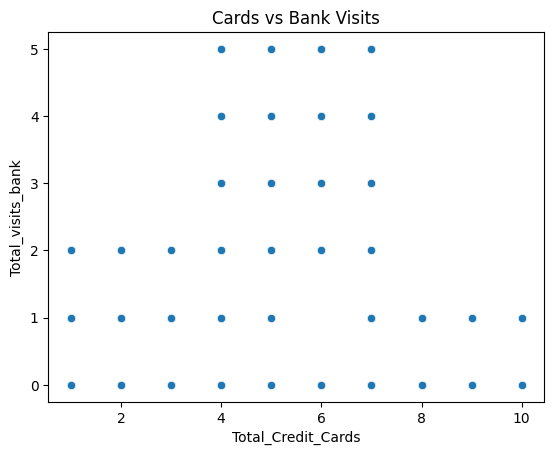

In [15]:
sns.scatterplot(x='Total_Credit_Cards', y='Total_visits_bank', data=df)
plt.title("Cards vs Bank Visits")
plt.show()


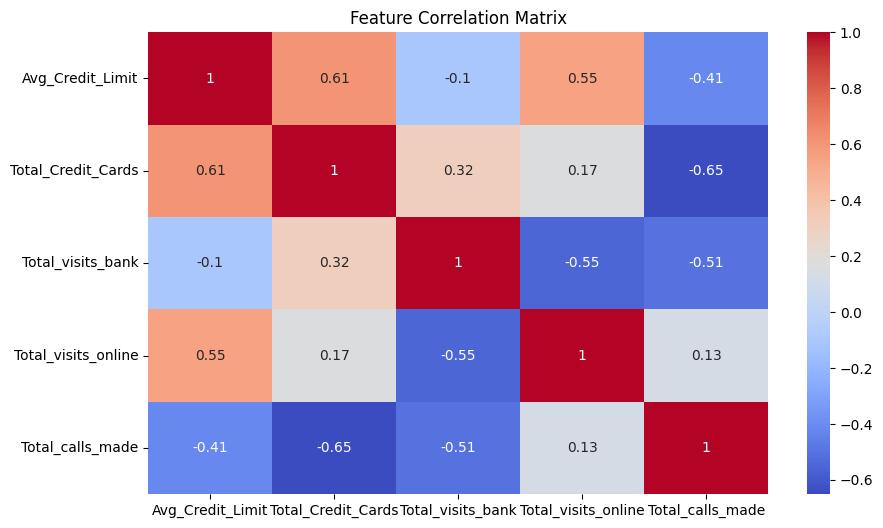

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [21]:
# Select Features for Clustering
features = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
x = df[features]

# Standardize the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


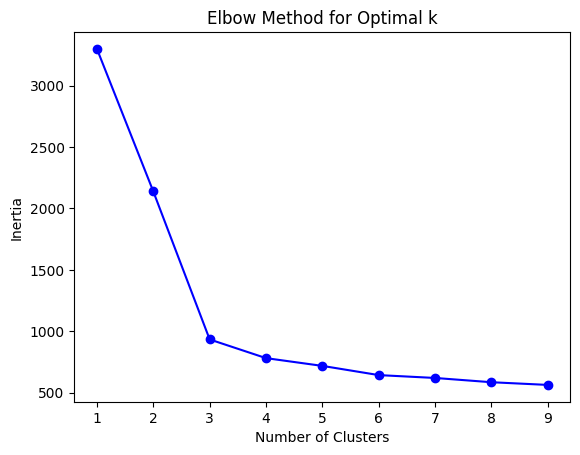

In [22]:
# Elbow Method to Determine Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


In [23]:
# Fit KMeans with Chosen k (e.g., k=3 based on the elbow curve)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

# Show how many customers are in each cluster
df['Cluster'].value_counts()


,count
Cluster,
0,386
2,224
1,50


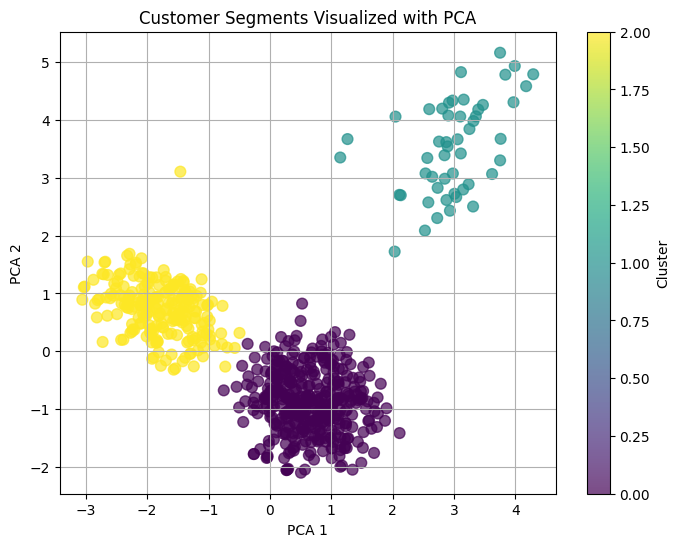

In [24]:
# Visualize Clusters in 2D with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['Cluster'], cmap='viridis', s=60, alpha=0.7)
plt.title('Customer Segments Visualized with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


In [25]:
# Cluster Profiling
# Get average values of each feature for each cluster to describe behavior
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,33782.38,5.52,3.49,0.98,2.00
1,141040.00,8.74,0.60,10.90,1.08
2,12174.11,2.41,0.93,3.55,6.87


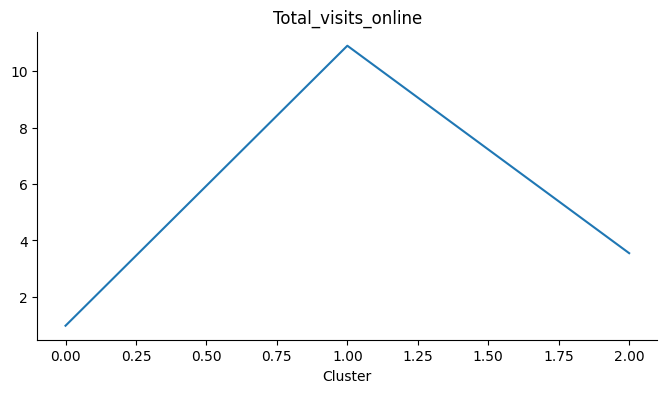

In [28]:
# @title Total_visits_online

from matplotlib import pyplot as plt
cluster_summary['Total_visits_online'].plot(kind='line', figsize=(8, 4), title='Total_visits_online')
plt.gca().spines[['top', 'right']].set_visible(False)

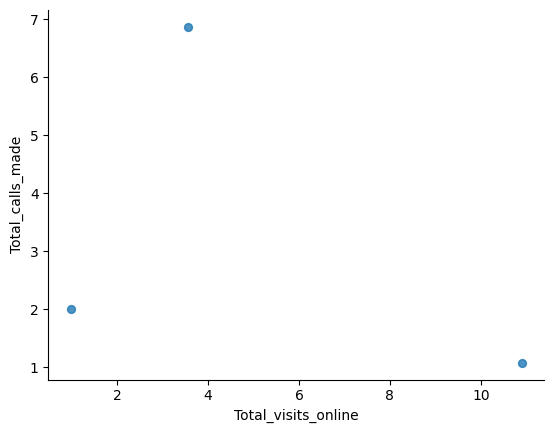

In [27]:
# @title Total_visits_online vs Total_calls_made

from matplotlib import pyplot as plt
cluster_summary.plot(kind='scatter', x='Total_visits_online', y='Total_calls_made', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)